# Linear regression model: RDU hourly temperature

Two-stage linear model:
1. **Climatology**: linear regression on day-of-year × hour-of-day Fourier terms (seasonal + diurnal cycle).
2. **Anomaly forecast**: ridge regression predicting the departure from climatology at each lead hour, from conditions at the forecast origin × lead-time decay.

Final prediction = climatology + predicted anomaly. Evaluated on a rolling-origin backtest against climatology and persistence baselines.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

TZ = "America/New_York"
HORIZON = 14 * 24                                   # 336 hourly predictions
CUTOFF = pd.Timestamp("2026-09-17 00:00", tz=TZ)    # forecast origin; nothing at/after this is used

CLIM_COLS = ["temperature", "dew_point_temperature", "sea_level_pressure"]

## 2. Load data on a complete hourly grid

In [2]:
raw = pd.read_csv("cleaned_data/rdu_51_clean.csv")
raw["hour"] = pd.to_datetime(raw["DATE"], utc=True).dt.floor("h")
raw = raw.drop_duplicates("hour").set_index("hour").sort_index()

# Full UTC hourly grid so that shifts/rolling windows are in real hours; missing hours stay NaN
grid = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
hourly = raw.reindex(grid)[CLIM_COLS]
hourly = hourly.loc[hourly.index < CUTOFF]

# Same temperatures indexed in local time (used for baselines and scoring)
temp_local = pd.Series(hourly["temperature"].values, index=hourly.index.tz_convert(TZ))

print("Hours on grid:", len(hourly))
print("Missing temperature hours:", hourly["temperature"].isna().sum())
print("Last hour available:", temp_local.index.max())

Hours on grid: 50044
Missing temperature hours: 163
Last hour available: 2026-09-16 23:00:00-04:00


## 3. Stage 1: climatology regression

Products of day-of-year and hour-of-day harmonics let the size and shape of the daily cycle change with the season.

In [3]:
def clim_basis(ts_utc, k_doy=3, k_hr=3):
    """Fourier design matrix: every (doy harmonic) x (hour harmonic) product."""
    t = ts_utc.tz_convert(TZ)
    doy = 2 * np.pi * (t.dayofyear.values - 1) / 365.25
    hr = 2 * np.pi * t.hour.values / 24
    d = [np.ones(len(t))] + [f(k * doy) for k in range(1, k_doy + 1) for f in (np.sin, np.cos)]
    h = [np.ones(len(t))] + [f(k * hr) for k in range(1, k_hr + 1) for f in (np.sin, np.cos)]
    return np.column_stack([a * b for a in d for b in h])[:, 1:]   # drop the constant (intercept handles it)


class Climatology:
    """Expected value of one variable for a given date and hour, fit only on data before `end`."""
    def __init__(self, col):
        self.col = col

    def fit(self, end):
        y = hourly.loc[hourly.index < end, self.col].dropna()
        self.model = LinearRegression().fit(clim_basis(y.index), y.values)
        return self

    def predict(self, ts_utc):
        return self.model.predict(clim_basis(ts_utc))

## 4. Stage 2: anomaly features at the forecast origin

All features use only hours strictly before the origin. Missing values are filled with 0, which means "no departure from climatology".

In [4]:
FEATURE_GROUPS = {
    "temp":     ["t_last", "t_6h", "t_24h", "t_72h", "t_7d"],   # temperature anomaly at several windows
    "dewpoint": ["td_24h"],                                    # moisture anomaly (air mass)
    "pressure": ["p_anom", "p_tend_6h", "p_tend_24h"],         # pressure level and trend (approaching systems)
}
DECAY_TAUS = [3, 12, 48, 168]   # hours; e-folding times for how fast each signal fades with lead time


def anomalies(clims):
    """Observed minus climatology for each variable, on the full hourly grid."""
    return pd.DataFrame({c: hourly[c].values - m.predict(hourly.index) for c, m in clims.items()},
                        index=hourly.index)


def origin_features(A, origins, groups):
    ta = A["temperature"]
    pres = hourly["sea_level_pressure"].ffill(limit=3)
    f = pd.DataFrame(index=A.index)
    f["t_last"] = ta.ffill(limit=3)
    f["t_6h"] = ta.rolling(6, min_periods=3).mean()
    f["t_24h"] = ta.rolling(24, min_periods=12).mean()
    f["t_72h"] = ta.rolling(72, min_periods=36).mean()
    f["t_7d"] = ta.rolling(168, min_periods=84).mean()
    f["td_24h"] = A["dew_point_temperature"].rolling(24, min_periods=12).mean()
    f["p_anom"] = A["sea_level_pressure"].ffill(limit=3)
    f["p_tend_6h"] = pres - pres.shift(6)
    f["p_tend_24h"] = pres - pres.shift(24)

    cols = [c for g in groups for c in FEATURE_GROUPS[g]]
    # The row for (origin - 1h) summarizes everything observed before the origin
    F = f[cols].reindex(origins - pd.Timedelta(hours=1)).fillna(0.0)
    return F.values, cols


def design(F, origins, cols):
    """Expand origin features over the 336 lead hours.

    - each feature x exp(-lead / tau): lets the model learn how fast each signal fades
    - short-lead temperature anomaly x target hour-of-day harmonics: an anomaly at midnight
      carries over differently to the night than to the afternoon
    """
    lead = np.arange(HORIZON)
    decay = np.column_stack([np.exp(-lead / tau) for tau in DECAY_TAUS])
    X = np.einsum("ok,lm->olkm", F, decay).reshape(len(F) * HORIZON, -1)
    names = [f"{c} x exp(-L/{tau}h)" for c in cols for tau in DECAY_TAUS]

    short = [i for i, c in enumerate(cols) if c in ("t_last", "t_6h", "t_24h")]
    if short:
        target_hr = np.array([
            pd.date_range(o, periods=HORIZON, freq="h").tz_convert(TZ).hour.values for o in origins
        ])                                                              # (n_origins, HORIZON)
        hr = 2 * np.pi * target_hr / 24
        H = np.stack([np.exp(-lead / 24) * f(k * hr) for k in (1, 2) for f in (np.sin, np.cos)], axis=-1)
        X2 = np.einsum("ok,olm->olkm", F[:, short], H).reshape(len(F) * HORIZON, -1)
        X = np.hstack([X, X2])
        names += [f"{cols[i]} x hour-{k}{fn}" for i in short for k in (1, 2) for fn in ("sin", "cos")]
    return X, names

## 5. The forecaster

In [5]:
class LinearForecaster:
    """Climatology regression + ridge regression on anomalies. Trained only on data before `end`."""

    def __init__(self, groups=("temp",), alpha=1.0):
        self.groups, self.alpha = list(groups), alpha

    def fit(self, end):
        end = end.tz_convert("UTC")
        self.clims = {c: Climatology(c).fit(end) for c in CLIM_COLS}
        self.A = anomalies(self.clims)

        # One training forecast per day, issued at LOCAL midnight (same as the real forecast),
        # with all 336 target hours ending before `end`
        first = (hourly.index.min().tz_convert(TZ) + pd.Timedelta(days=8)).normalize()
        last = (end - pd.Timedelta(hours=HORIZON)).tz_convert(TZ)
        origins = pd.date_range(first, last, freq="D", tz=TZ).tz_convert("UTC")

        F, cols = origin_features(self.A, origins, self.groups)
        X, self.feature_names = design(F, origins, cols)
        targets = origins.repeat(HORIZON) + pd.to_timedelta(np.tile(np.arange(HORIZON), len(origins)), unit="h")
        y = self.A["temperature"].reindex(targets).values
        ok = ~np.isnan(y)

        self.model = make_pipeline(StandardScaler(), Ridge(alpha=self.alpha)).fit(X[ok], y[ok])
        self.n_train = int(ok.sum())
        return self

    def predict(self, origin):
        """336 hourly temperatures starting at `origin` (local midnight)."""
        o = pd.DatetimeIndex([origin.tz_convert("UTC")])
        F, cols = origin_features(self.A, o, self.groups)
        X, _ = design(F, o, cols)
        hours = pd.date_range(origin, periods=HORIZON, freq="h").tz_convert("UTC")
        return self.clims["temperature"].predict(hours) + self.model.predict(X)

    def climatology_only(self, origin):
        hours = pd.date_range(origin, periods=HORIZON, freq="h").tz_convert("UTC")
        return self.clims["temperature"].predict(hours)

## 6. Baselines

In [6]:
def climatology_baseline(origin):
    """Mean temperature for the same local hour within +/-7 days of the date, prior years only."""
    past = temp_local[temp_local.index < origin].dropna()
    sums, counts = np.zeros((367, 24)), np.zeros((367, 24))
    np.add.at(sums, (past.index.dayofyear.values, past.index.hour.values), past.values)
    np.add.at(counts, (past.index.dayofyear.values, past.index.hour.values), 1)
    out = []
    for h in pd.date_range(origin, periods=HORIZON, freq="h", tz=TZ):
        days = (np.arange(h.dayofyear - 7, h.dayofyear + 8) - 1) % 366 + 1
        out.append(sums[days, h.hour].sum() / counts[days, h.hour].sum())
    return np.array(out)


def persistence_baseline(origin):
    """The last 24 observed hours, repeated for 14 days."""
    prev = temp_local.reindex(pd.date_range(origin - pd.Timedelta(hours=24), periods=24, freq="h", tz=TZ))
    return np.tile(prev.interpolate(limit_direction="both").values, 14)

## 7. Rolling-origin backtest

Forecast origins every 3 days from Aug 15 to Oct 15 in 2022–2025 (84 forecasts). For each season the model is retrained on data before that season's first origin, so no test hour is ever seen in training.

In [7]:
BACKTEST_YEARS = [2022, 2023, 2024, 2025]


def season_origins(year):
    return pd.date_range(f"{year}-08-15", f"{year}-10-15", freq="3D", tz=TZ)


def score(pred, origin, model, rows):
    actual = temp_local.reindex(pd.date_range(origin, periods=HORIZON, freq="h", tz=TZ)).values
    err = pred - actual
    for d in range(14):
        e = err[d * 24:(d + 1) * 24]
        e = e[~np.isnan(e)]
        rows.append({"origin": origin, "model": model, "lead_day": d + 1,
                     "abs_err": np.abs(e).sum(), "sq_err": (e ** 2).sum(), "n": len(e)})


def backtest(make_model, name, include_baselines=False):
    rows = []
    for year in BACKTEST_YEARS:
        origins = season_origins(year)
        m = make_model().fit(origins[0])
        for o in origins:
            score(m.predict(o), o, name, rows)
            if include_baselines:
                score(m.climatology_only(o), o, "fourier climatology", rows)
                score(climatology_baseline(o), o, "climatology baseline", rows)
                score(persistence_baseline(o), o, "persistence baseline", rows)
    return pd.DataFrame(rows)


def summarize(results):
    per = results.groupby(["model", "origin"])[["abs_err", "sq_err", "n"]].sum()
    per = pd.DataFrame({"MAE": per.abs_err / per.n, "RMSE": np.sqrt(per.sq_err / per.n)})
    out = per.groupby("model").agg(["mean", "std"]).round(2)
    return out.sort_values(("MAE", "mean"))


results = backtest(lambda: LinearForecaster(), "linear", include_baselines=True)
summarize(results)

MAE        RMSE      
                      mean   std  mean   std
model                                       
linear                2.77  0.59  3.36  0.67
fourier climatology   2.86  0.59  3.44  0.66
climatology baseline  2.96  0.72  3.57  0.81
persistence baseline  3.81  1.38  4.62  1.51

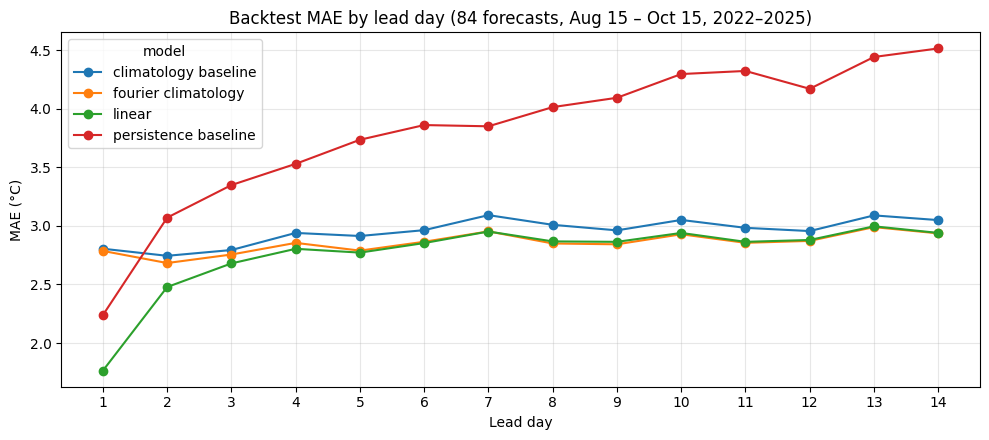

model,climatology baseline,fourier climatology,linear,persistence baseline
lead_day,,,,
1,2.81,2.79,1.76,2.24
2,2.74,2.68,2.48,3.07
3,2.79,2.76,2.68,3.35
4,2.94,2.86,2.80,3.53
5,2.91,2.79,2.77,3.74
6,2.96,2.86,2.85,3.86
7,3.09,2.95,2.95,3.85
8,3.01,2.85,2.87,4.02
9,2.96,2.84,2.86,4.09


In [8]:
by_day = results.groupby(["model", "lead_day"])[["abs_err", "n"]].sum()
by_day = (by_day.abs_err / by_day.n).unstack(0)

ax = by_day.plot(figsize=(10, 4.5), marker="o")
ax.set_xlabel("Lead day")
ax.set_ylabel("MAE (°C)")
ax.set_title("Backtest MAE by lead day (84 forecasts, Aug 15 – Oct 15, 2022–2025)")
ax.set_xticks(range(1, 15))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

by_day.round(2)

## 8. Feature-group ablation

Same backtest, adding one feature group at a time. Dew point and pressure did not lower the error, so the default model uses the temperature-anomaly features only.

In [9]:
ablation = [
    ("temp", ["temp"]),
    ("temp + dewpoint", ["temp", "dewpoint"]),
    ("temp + dewpoint + pressure", ["temp", "dewpoint", "pressure"]),
]
abl_results = pd.concat(
    [results[results.model.isin(["fourier climatology"])]] +
    [backtest(lambda g=g: LinearForecaster(groups=g), name) for name, g in ablation]
)
summarize(abl_results)

MAE        RMSE      
                            mean   std  mean   std
model                                             
temp                        2.77  0.59  3.36  0.67
temp + dewpoint + pressure  2.77  0.58  3.37  0.66
temp + dewpoint             2.78  0.61  3.38  0.69
fourier climatology         2.86  0.59  3.44  0.66

## 9. Example: forecast issued 2025-09-17

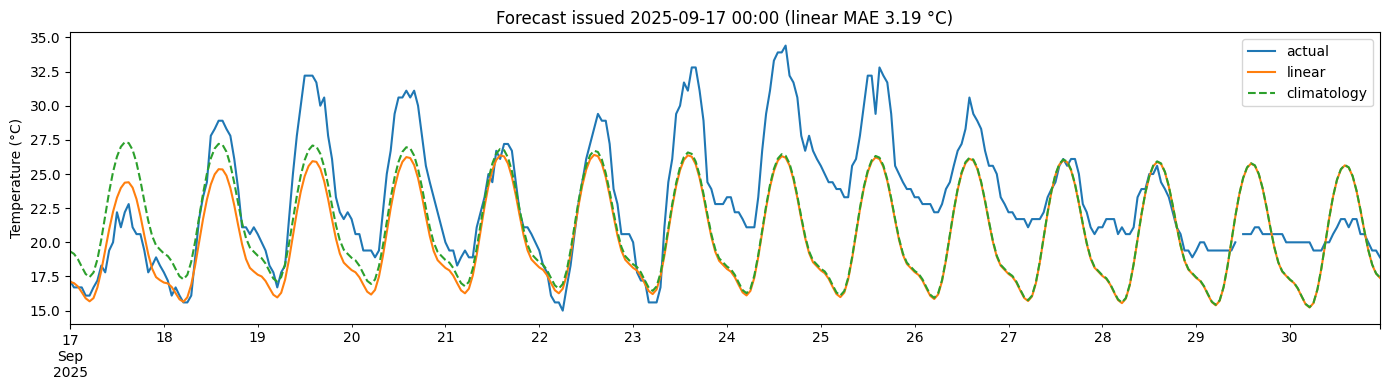

In [10]:
example_origin = pd.Timestamp("2025-09-17 00:00", tz=TZ)
m = LinearForecaster().fit(example_origin)
hours = pd.date_range(example_origin, periods=HORIZON, freq="h", tz=TZ)

example = pd.DataFrame({
    "actual": temp_local.reindex(hours).values,
    "linear": m.predict(example_origin),
    "climatology": m.climatology_only(example_origin),
}, index=hours)

mae = (example.linear - example.actual).abs().mean()
ax = example.plot(figsize=(14, 4), style={"climatology": "--"})
ax.set_title(f"Forecast issued 2025-09-17 00:00 (linear MAE {mae:.2f} °C)")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

## 10. Largest anomaly-model coefficients

Coefficients are on standardized features (°C per standard deviation of the feature). The anomaly windows are correlated with each other, so read individual signs with caution; the lead-day MAE plot is the more reliable view of what the model learned.

In [11]:
coefs = pd.Series(m.model[-1].coef_, index=m.feature_names)
coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15).round(3)

t_6h x exp(-L/48h)       1.800
t_last x exp(-L/12h)     1.209
t_6h x exp(-L/12h)      -0.928
t_24h x exp(-L/48h)     -0.650
t_last x hour-1cos       0.482
t_last x exp(-L/3h)     -0.438
t_6h x hour-1sin        -0.378
t_last x exp(-L/168h)   -0.365
t_last x hour-1sin       0.351
t_7d x exp(-L/48h)      -0.343
t_last x exp(-L/48h)    -0.327
t_72h x exp(-L/48h)      0.307
t_6h x hour-1cos        -0.290
t_7d x exp(-L/168h)      0.266
t_7d x exp(-L/12h)       0.184
dtype: float64

## 11. Final forecast: Sep 17–30, 2026

Retrained on all data before 2026-09-17 00:00 local.

Training rows: 691557
Forecast hours: 336
Saved: rdu_linear_predictions.csv


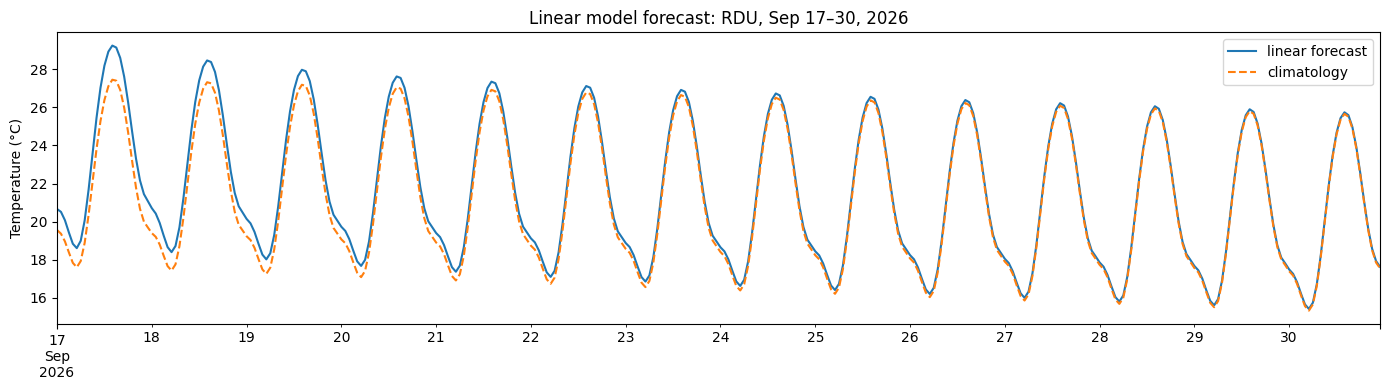

In [12]:
final = LinearForecaster().fit(CUTOFF)
forecast_hours = pd.date_range(CUTOFF, periods=HORIZON, freq="h", tz=TZ)

forecast = pd.DataFrame({
    "hour_local": forecast_hours,
    "predicted_temperature": final.predict(CUTOFF),
})
forecast.to_csv("rdu_linear_predictions.csv", index=False)

print("Training rows:", final.n_train)
print("Forecast hours:", len(forecast))
print("Saved: rdu_linear_predictions.csv")

plot_df = pd.DataFrame({
    "linear forecast": forecast["predicted_temperature"].values,
    "climatology": final.climatology_only(CUTOFF),
}, index=forecast_hours)
ax = plot_df.plot(figsize=(14, 4), style={"climatology": "--"})
ax.set_title("Linear model forecast: RDU, Sep 17–30, 2026")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()